In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout, Reshape, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
tf.keras.preprocessing.sequence.TimeseriesGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LeakyReLU
tf.keras.callbacks.EarlyStopping
from sklearn.metrics import mean_absolute_error,mean_squared_error
mpl.rcParams['figure.figsize']= (20,10)
mpl.rcParams['axes.grid']= False

In [ ]:
load_data = pd.read_csv('/content/2018-2022 data - new  and modified.csv')

In [ ]:
load_data["Date & Time"] = pd.to_datetime(load_data["Date & Time"], dayfirst=True)
load_data['Year']=load_data['Date & Time'].dt.year
load_data['Month']=load_data['Date & Time'].dt.month
load_data['Day']=load_data['Date & Time'].dt.day
load_data['Hour']=load_data['Date & Time'].dt.hour
load_data

,Date,Time,Date & Time,Working days,temparature-C,Humidity,NLDC Demand,Unnamed: 7,Year,Month,Day,Hour
0,01.01.2018,1:00,2018-01-01 01:00:00,1,18.02,86.12,155.0,NaN,2018,1,1,1
1,01.01.2018,2:00,2018-01-01 02:00:00,1,17.76,86.00,147.0,NaN,2018,1,1,2
2,01.01.2018,3:00,2018-01-01 03:00:00,1,17.25,87.00,142.0,NaN,2018,1,1,3
3,01.01.2018,4:00,2018-01-01 04:00:00,1,16.61,89.31,135.0,NaN,2018,1,1,4
4,01.01.2018,5:00,2018-01-01 05:00:00,1,15.77,92.44,137.0,NaN,2018,1,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...
43073,31.12.2022,20:00,2022-12-31 20:00:00,0,15.55,83.75,268.0,NaN,2022,12,31,20
43074,31.12.2022,21:00,2022-12-31 21:00:00,0,14.76,86.31,261.0,,2022,12,31,21
43075,31.12.2022,22:00,2022-12-31 22:00:00,0,14.15,87.94,293.0,NaN,2022,12,31,22
43076,31.12.2022,23:00,2022-12-31 23:00:00,0,13.89,87.56,356.0,NaN,2022,12,31,23


In [ ]:
df=load_data[['NLDC Demand','temparature-C','Humidity','Hour','Day','Month','Year']]

In [ ]:
df = df[df['NLDC Demand'] != 0]
df.reset_index(drop=True, inplace=True)

In [ ]:
df = df.dropna(axis=0)

In [ ]:

Q1 = np.percentile(df['NLDC Demand'], 25)
Q3 = np.percentile(df['NLDC Demand'], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['NLDC Demand'] < lower_bound) | (df['NLDC Demand'] > upper_bound)]
print(outliers)

       NLDC Demand  temparature-C  Humidity  Hour  Day  Month  Year
12332        780.0          27.41     88.56    23   29      6  2019
13312        687.0          28.54     91.75    19    9      8  2019
19119        904.0          25.68     59.06    18    7      4  2020
27472       4588.0          28.24     44.94    19   21      3  2021
28534        970.0          23.60     82.00     1    5      5  2021
...            ...            ...       ...   ...  ...    ...   ...
40097        638.0          25.32     90.50    21   28      9  2022
40169        652.0          29.87     76.00    21    1     10  2022
40171        635.0          27.92     88.50    23    1     10  2022
40172        636.0          27.42     89.06     0    1     10  2022
40173        649.0          27.05     89.31     1    2     10  2022

[671 rows x 7 columns]


In [ ]:
df['NLDC Demand'] = np.where(df['NLDC Demand'] < lower_bound, lower_bound, df['NLDC Demand'])
df['NLDC Demand'] = np.where(df['NLDC Demand'] > upper_bound, upper_bound, df['NLDC Demand'])

print(df)

       NLDC Demand  temparature-C  Humidity  Hour  Day  Month  Year
0            155.0          18.02     86.12     1    1      1  2018
1            147.0          17.76     86.00     2    1      1  2018
2            142.0          17.25     87.00     3    1      1  2018
3            135.0          16.61     89.31     4    1      1  2018
4            137.0          15.77     92.44     5    1      1  2018
...            ...            ...       ...   ...  ...    ...   ...
42352        268.0          15.55     83.75    20   31     12  2022
42353        261.0          14.76     86.31    21   31     12  2022
42354        293.0          14.15     87.94    22   31     12  2022
42355        356.0          13.89     87.56    23   31     12  2022
42356        351.0          13.76     86.31     0   31     12  2022

[42165 rows x 7 columns]


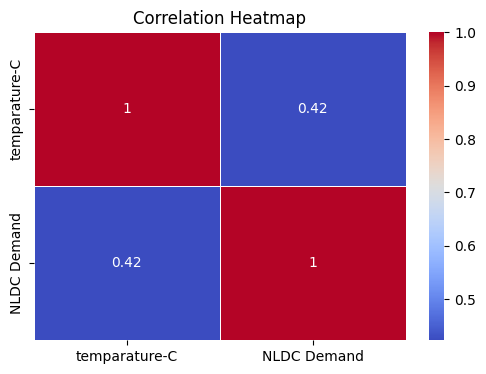

In [ ]:
corr = df[['temparature-C', 'NLDC Demand']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

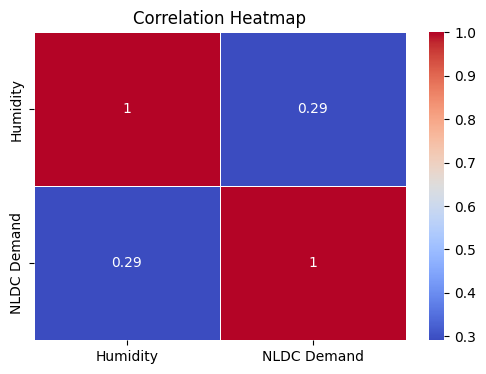

In [ ]:
corr = df[['Humidity', 'NLDC Demand']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
scaler=MinMaxScaler()
input_scaled= scaler.fit_transform(df)

In [ ]:
import joblib
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
input_scaled = scaler.fit_transform(df)
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
train_size= 26280
val_size= 8600
test_size= 8197
train_data= input_scaled[:train_size]
train_data.shape
val_data= input_scaled[train_size:train_size+val_size]
val_data.shape
test_data= input_scaled[train_size+val_size:train_size + val_size+test_size]
test_data.shape

(7285, 7)

In [ ]:
def create_sequence(data, input_length):
    X = []
    Y = []
    for i in range(len(data) - input_length):
        X.append(data[i:i + input_length, :])
        Y.append(data[i + input_length, 0])    
    return np.array(X), np.array(Y)

In [ ]:
input_length=1
x_train, y_train = create_sequence(train_data, input_length)
x_val, y_val = create_sequence(val_data, input_length)
x_test, y_test = create_sequence(test_data, input_length)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], x_train.shape[2]))
x_val = np.reshape(x_val, (x_val.shape[0], x_val.shape[1], x_val.shape[2]))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], x_test.shape[2]))
print(x_train.shape, x_val.shape, x_test.shape)

(26279, 1, 7) (8599, 1, 7) (7284, 1, 7)


In [ ]:
lstm_model1 = Sequential()
lstm_model1.add(LSTM(164,
                     activation='tanh',input_shape=(x_train.shape[1], x_train.shape[2])))
lstm_model1.add(Dense(1))
lstm_model1.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.0001))
lstm_model1.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 164)                 │         112,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 112,997 (441.39 KB)

 Trainable params: 112,997 (441.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
learning_rate_reduction = ReduceLROnPlateau(
    monitor='loss',   
    patience=2,      
    factor=0.5,  
    min_lr = 0.00000001,   
    verbose=1,    
    restore_best_weights = True
    )

In [ ]:
early_stopping = [tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True)]

In [ ]:
history= lstm_model1.fit(
    x_train, y_train,
    epochs = 20,
    batch_size= 10,
    validation_data= (x_val, y_val),
    shuffle= False,
    callbacks= [learning_rate_reduction]
)

Epoch 1/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0171 - val_loss: 0.0174 - learning_rate: 1.0000e-04
Epoch 2/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0034 - val_loss: 0.0049 - learning_rate: 1.0000e-04
Epoch 3/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 0.0021 - val_loss: 0.0021 - learning_rate: 1.0000e-04
Epoch 4/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0018 - val_loss: 0.0021 - learning_rate: 1.0000e-04
Epoch 5/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0018 - val_loss: 0.0022 - learning_rate: 1.0000e-04
Epoch 6/20
2623/2628 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0018 - val_loss: 0.0022 - learning_rate: 1.0000e-04
Epoch 7/20
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0018 - val_loss: 0.0022 - learning_rate: 5.0000e-05
Epoch 8/20
2615/2628 ━━━━━━━━━━━━━━━━━━━━ 0s 4m

In [ ]:
lstm_model1.evaluate(x_test,y_test, verbose=0)
prediction=lstm_model1.predict(x_test)
prediction.shape

228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(7284, 1)

In [ ]:
data_step1 = x_test[:,0,:] 
selected_data = prediction[:,0]

In [ ]:
df1 = pd.DataFrame(data_step1)
df2 = pd.DataFrame(selected_data)

In [ ]:
df_predicted = pd.concat([ df2,df1.iloc[:, 1:]],axis=1)
df_predicted.shape

(7284, 7)

In [ ]:
r_trans = scaler.inverse_transform(df_predicted)
df_final=df[data_step1.shape[0]*-1:]
df_final['load_predicted']=r_trans[:,0]
df_final['Date']=load_data.loc[35042:43077, 'Date']

<ipython-input-24-795e2f8d1e7e>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['load_predicted']=r_trans[:,0]
<ipython-input-24-795e2f8d1e7e>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Date']=load_data.loc[35042:43077, 'Date']


In [ ]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
print(df_final.iloc[:,[8, 0,7]])

             Date  NLDC Demand  load_predicted
35073  01.02.2022       268.00      267.028398
35074  01.02.2022       266.00      278.196269
35075  01.02.2022       285.00      278.160879
35076  01.02.2022       286.00      294.993720
35077  01.02.2022       280.00      296.686162
35078  01.02.2022       272.00      290.795890
35079  01.02.2022       271.00      280.831786
35080  01.02.2022       328.00      278.343755
35081  01.02.2022       366.00      325.704596
35082  01.02.2022       349.00      356.692560
35083  01.02.2022       342.00      341.462158
35084  01.02.2022       333.00      334.971662
35085  01.02.2022       293.00      300.687496
35086  02.02.2022       272.00      269.037696
35087  02.02.2022       249.00      252.564570
35088  02.02.2022       237.00      234.406114
35089  02.02.2022       224.00      225.070418
35090  02.02.2022       221.00      215.008481
35091  02.02.2022       217.00      213.046893
35092  02.02.2022       221.00      212.264001
35093  02.02.

In [ ]:
MAE = mean_absolute_error(df_final['NLDC Demand'],df_final['load_predicted'])
MAE

18.549686838757

In [ ]:
mse= mean_squared_error(df_final['NLDC Demand'],df_final['load_predicted'])
mse

857.705259414643

In [ ]:
rmse = np.sqrt(mse)
rmse

29.286605460767266

In [ ]:

def mape(a, p):
    a, p = np.array(a), np.array(p)
    return np.mean(np.abs((a - p) / a)) * 100

MAPE = mape(df_final['NLDC Demand'], df_final['load_predicted'])
print("Mean Absolute Percentage Error (MAPE):", MAPE)

Mean Absolute Percentage Error (MAPE): 5.371870221679309
